# 72-hour SHARP rolling uncertainty replay
**Notebook 04 · Bamidele Akinwumi · exploratory candidate-label experiment**

## tl;dr
**Rolling updates improve flare coverage in this replay, with substantially more ambiguous forecasts.** Earlier 2015–2019 development selected a 180-day lookback for both models. At the primary 90% target, GRU flare coverage increases from 73.5% to 87.9% on Cycle 25 and from 43.5% to 78.3% in partial 2026. Both-label sets increase from 3.5% to 36.0% and from 2.3% to 37.4%, respectively. The observed flare coverage still falls below target.

The replay includes 2,975 daily update dates. Each update uses only outcomes assumed available after the 72-hour forecast window plus 24 hours. No 2020 scored cases are available; low-support guards affect 8.7% of evaluated Cycle-25 windows and none of the 2026 windows for the selected method. These are provisional retrospective results, not prospective operational validation.

## Context & Methods

Notebook 03 exposed poor transfer of fixed conformal thresholds. This experiment compares those exact **fixed class-conditional thresholds** with **90-, 180- and 365-day rolling class-conditional thresholds**. Pooled prediction is retained in Notebook 03; this notebook focuses on class coverage.

At **00:00 UTC each day**, select calibration windows issued in the preceding lookback interval whose complete 72-hour outcome window plus an assumed **24-hour reporting delay** has elapsed. Apply the resulting thresholds to that day's inherited issue-time cases. Later outcomes cannot alter earlier sets. Both classes use the same delayed feedback rule, including positive outcomes.

Choose one method per backbone on **July 2015–2019 development outcomes**, at the primary 90% target: minimize the worst class coverage deficit below 90%, then mean set size, then declared candidate order. The fixed baseline remains a candidate. Reuse that choice at the 95% sensitivity. Save the choice before scoring later periods; report all declared candidates without changing the choice.

### Key Assumptions

- Outcomes are provisional M/X start-within-72-hour labels for the primary NOAA region. Counts refer to overlapping forecast windows.
- Models and probability mappings remain frozen. Rolling calibration does use matured earlier Cycle-25/2026 labels: this tests sequential updating, not label-free cycle transfer.
- A class needs at least **50 windows from five mapped region components** in the lookback. Otherwise include that class automatically. These are declared support heuristics, not a coverage theorem. Both labels may be included when support is weak; this is reported explicitly.
- Missing SHARP inputs receive no set; unknown outcomes receive sets when inputs exist but never enter calibration or metrics. No 2020 scored cases are available, so 2021 starts without recent observations.
- Historical reporting/revision times are unverified. The 24-hour delay is an assumption, and this is a retrospective replay on native cases rather than a complete prospective forecast schedule.
- This implements rolling quantiles at fixed alpha. It does **not** implement an adaptive-conformal error-feedback controller or claim its guarantees. Temporal dependence and drift can still break nominal coverage.
- The experiment was designed after inspecting earlier retrospective results; it is exploratory. The 2015–2019 block is now used for rolling-method development and cannot be presented as untouched validation for later policy claims.
- Bootstrap intervals are conditional paired resampling of already-issued sets. They do not rerun the sequential updates and exclude model, calibration-sample, label and method-selection uncertainty.

Related primary sources: [Barber et al., Conformal prediction beyond exchangeability](https://arxiv.org/abs/2202.13415) explains why changing distributions matter; [Gibbs & Candès, Adaptive Conformal Inference](https://proceedings.neurips.cc/paper/2021/hash/0d441de75945e5acbc865406fc9a2559-Abstract.html) describes a distinct adaptive method for later comparison. This notebook's windows, support guards and selection rule are experimental choices, not implementations of those papers' theorems.

## Data
### 1. Environment and pinned inputs
Use the same local training kernel and `requirements-notebook.txt`; no new dependencies, cloud jobs or downloads are needed. Functions are embedded so no repository Python imports are required.

In [1]:
from datetime import datetime, timezone
from decimal import Decimal, ROUND_CEILING
import hashlib
import json
from pathlib import Path
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown
WORKSPACE=Path.cwd()
if WORKSPACE.name=='notebooks':WORKSPACE=WORKSPACE.parent
plt.rcParams.update({'font.size':11,'axes.spines.top':False,'axes.spines.right':False,'figure.dpi':115,'axes.titleweight':'bold'})
COLORS={'fixed_2015':'#245A81','selected':'#B36B19'}
PERIOD_NAMES={'retrospective_cycle25':'2021–2025','supplementary_2026':'2026 (partial)'}
print({'numpy':np.__version__,'pandas':pd.__version__})

{'numpy': '2.3.5', 'pandas': '2.2.3'}


In [2]:
CONFIG=json.loads(r'''{
  "experiment": "sharp72_rolling_conformal_candidate_v1",
  "parent_dir": "outputs/sharp72_calibration_v1_20261002T083245963780Z",
  "calibration_summary_sha256": "bbdba037ac756ef4ea0b71299439f76fe1f0135595cb2ed0542afe2cbceb9811",
  "fixed_dir": "outputs/sharp72_conformal_v1_20261002T085647154969Z",
  "fixed_summary_sha256": "bcb708925b9f4a7b1a44cac24dabde59140a76281195ced2ecd44a879dc950b5",
  "dataset_manifest_sha256": "7bb88614482cacd5fafb145d88345132a6cf97b25b8313dbefd90b08ac5b9d27",
  "horizon": 72,
  "scope": "primary",
  "history_start": "2015-01-01",
  "replay_start": "2015-07-01",
  "policy_start": "2015-07-01",
  "policy_end": "2020-01-01",
  "reporting_delay_hours": 24,
  "reporting_delay_status": "Assumed; historical delivery and revision times are unverified",
  "update_cadence": "00:00 UTC daily, applied to inherited native issue-time cases",
  "lookback_days": [
    90,
    180,
    365
  ],
  "window_membership": "issue in [update - lookback, update), outcome_end + reporting_delay <= update",
  "minimum_windows_per_class": 50,
  "minimum_region_components_per_class": 5,
  "insufficient_support": "Always include the unsupported class; do not recycle stale thresholds",
  "models": [
    "gru",
    "logistic"
  ],
  "alphas": [
    0.1,
    0.05
  ],
  "primary_alpha": 0.1,
  "candidate_methods": [
    "fixed_2015",
    "rolling_90d",
    "rolling_180d",
    "rolling_365d"
  ],
  "selection": "Per backbone at alpha 0.1 on policy_validation: minimize maximum class coverage deficit below 0.9; then mean set size; then declared order. Retain same selected method at alpha 0.05.",
  "evaluation_roles": [
    "retrospective_cycle25",
    "supplementary_2026"
  ],
  "bootstrap_repetitions": 1000,
  "bootstrap_seed": 16180,
  "bootstrap_groups": [
    "region_component",
    "calendar_7day_UTC"
  ],
  "bootstrap_scope": "Conditional paired resampling of issued sets; does not rerun the sequential adaptation"
}''')
PARENT_DIR=WORKSPACE/CONFIG['parent_dir']
FIXED_DIR=WORKSPACE/CONFIG['fixed_dir']
DATASET_DIR=WORKSPACE/'data/processed/training_snapshot_20261002/gray_box_aligned_v1'
OUTPUT_DIR=WORKSPACE/'outputs'/('sharp72_rolling_v1_'+datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ'))
print('New run:',OUTPUT_DIR)
display(pd.DataFrame([{'Stage':'Threshold update','Rule':CONFIG['window_membership']},
    {'Stage':'Method selection','Rule':CONFIG['selection']},
    {'Stage':'Low support','Rule':CONFIG['insufficient_support']}]))

New run: /Users/mac/Documents/ChatGPT/Imaging_Project/gray-box-solar-flare-forecasting/outputs/sharp72_rolling_v1_20261002T100951575030Z


,Stage,Rule
0,Threshold update,"issue in [update - lookback, update), outcome_..."
1,Method selection,Per backbone at alpha 0.1 on policy_validation...
2,Low support,Always include the unsupported class; do not r...


### 2. Reuse the verified conformal definitions and source checks
Exact finite-sample ranks, inclusive ties and set encoding follow Notebook 03. A blank set is distinct from an empty set.

In [3]:
def sha256(path):
    with Path(path).open('rb') as stream:
        return hashlib.file_digest(stream, 'sha256').hexdigest()

def save_json(path, value):
    Path(path).write_text(json.dumps(value, indent=2, allow_nan=False) + '\n')

def validate_probabilities(p, y=None):
    p = np.asarray(p, dtype=float)
    if p.ndim != 1 or not np.isfinite(p).all() or ((p < 0) | (p > 1)).any():
        raise ValueError('Probabilities must be a finite vector in [0,1]')
    if y is not None and (np.shape(y) != p.shape or not np.isin(y, [0, 1]).all()):
        raise ValueError('Unknown outcomes cannot enter conformal fitting or metrics')
    return p

def finite_sample_threshold(scores, alpha):
    scores = validate_probabilities(scores)
    a = Decimal(str(alpha))
    if not 0 < a < 1:
        raise ValueError('alpha must be strictly between zero and one')
    n = len(scores)
    rank = int((Decimal(n + 1) * (1-a)).to_integral_value(rounding=ROUND_CEILING))
    # A missing class or rank n+1 means +infinity, represented by JSON null.
    threshold = float(np.partition(scores, rank-1)[rank-1]) if rank <= n else None
    return {'n': n, 'rank': rank, 'threshold': threshold,
            'include_all': threshold is None}

def predict_sets(p, parameters):
    p = validate_probabilities(p)
    scores = np.column_stack([p, 1-p])
    q = [np.inf if parameters['thresholds'][str(k)]['include_all'] else parameters['thresholds'][str(k)]['threshold'] for k in [0, 1]]
    # Inclusive ties are conservative; no randomized tie-breaking or forced singleton.
    return scores <= np.asarray(q)

def set_metrics(y, sets):
    y = np.asarray(y)
    sets = np.asarray(sets)
    if not len(y) or sets.shape != (len(y), 2) or sets.dtype != bool or not np.isin(y, [0, 1]).all():
        raise ValueError('Need nonempty known binary outcomes and boolean prediction sets')
    y = y.astype(int)
    size = sets.sum(axis=1)
    covered = sets[np.arange(len(y)), y]
    singleton = size == 1
    counts = {'empty': size == 0, 'nonflare_only': (size == 1) & sets[:, 0],
              'flare_only': (size == 1) & sets[:, 1], 'both': size == 2}
    result = {'cases': len(y), 'nonflare_cases': int((y == 0).sum()), 'flare_cases': int((y == 1).sum()),
              'covered': int(covered.sum()), 'coverage': float(covered.mean()), 'mean_set_size': float(size.mean()),
              'singleton_cases': int(singleton.sum()), 'singleton_fraction': float(singleton.mean()),
              'singleton_error': float((~covered[singleton]).mean()) if singleton.any() else None}
    for label, name in [(0, 'nonflare'), (1, 'flare')]:
        selected = y == label
        result[f'{name}_covered'] = int(covered[selected].sum())
        result[f'{name}_coverage'] = float(covered[selected].mean()) if selected.any() else None
    for name, selected in counts.items():
        result[f'{name}_count'] = int(selected.sum())
        result[f'{name}_fraction'] = float(selected.mean())
    result['flare_singleton_nonflare_count'] = int(((y == 1) & counts['nonflare_only']).sum())
    result['flare_singleton_nonflare_rate'] = result['flare_singleton_nonflare_count'] / result['flare_cases'] if result['flare_cases'] else None
    return result

def coverage_bootstrap(y, sets, groups, repetitions=1000, seed=31415):
    y = np.asarray(y, dtype=int)
    set_metrics(y, sets)
    if pd.isna(groups).any():
        raise ValueError('Missing resampling group')
    covered = sets[np.arange(len(y)), y]
    raw = {'group': np.asarray(groups)}
    for name, selected in [('all', np.ones(len(y), dtype=bool)), ('nonflare', y == 0), ('flare', y == 1)]:
        raw[name + '_n'] = selected.astype(int)
        raw[name + '_covered'] = (covered & selected).astype(int)
    grouped = pd.DataFrame(raw).groupby('group', sort=True).sum()
    n = len(grouped)
    weights = np.random.default_rng(seed).multinomial(n, np.full(n, 1/n), size=repetitions)
    totals = weights @ grouped.to_numpy()
    sampled = dict(zip(grouped.columns, totals.T))
    rows = []
    for name in ['all', 'nonflare', 'flare']:
        denom = int(grouped[name + '_n'].sum())
        supported_groups = int(grouped[name + '_n'].gt(0).sum())
        valid = sampled[name + '_n'] > 0
        draws = sampled[name + '_covered'][valid] / sampled[name + '_n'][valid]
        estimable = supported_groups >= 2 and valid.sum() >= .95 * repetitions
        low, high = np.quantile(draws, [.025, .975]) if estimable else (None, None)
        rows.append({'population': name, 'cases': denom, 'groups': n, 'groups_with_class': supported_groups,
                     'coverage': float(grouped[name + '_covered'].sum()/denom) if denom else None,
                     'low': float(low) if low is not None else None, 'high': float(high) if high is not None else None,
                     'valid_repetitions': int(valid.sum()), 'interval_status': 'conditional_cluster_percentile' if estimable else 'insufficient_group_support'})
    return rows

def load_sources(parent_dir, dataset, config):
    if sha256(parent_dir / 'summary.json') != config['calibration_summary_sha256']:
        raise ValueError('Frozen calibration summary changed')
    parent = json.loads((parent_dir / 'summary.json').read_text())
    for name, expected in parent['output_sha256'].items():
        if sha256(parent_dir / name) != expected:
            raise ValueError(f'Frozen calibration artifact changed: {name}')
    contract = json.loads((parent_dir / 'run_contract.json').read_text())
    if contract['config']['horizon'] != 72 or contract['config']['scope'] != 'primary':
        raise ValueError('Wrong parent target')
    if config['horizon'] != 72 or config['scope'] != 'primary':
        raise ValueError('This experiment is for 72h primary targets')
    if sha256(dataset / 'manifest.json') != config['dataset_manifest_sha256']:
        raise ValueError('Dataset manifest changed')
    manifest = json.loads((dataset / 'manifest.json').read_text())
    if sha256(dataset / 'master_cases.csv.gz') != manifest['outputs']['master_cases.csv.gz']['sha256']:
        raise ValueError('Master-case table changed')
    master = pd.read_csv(dataset / 'master_cases.csv.gz', low_memory=False)
    frame = pd.read_csv(parent_dir / 'calibrated_predictions.csv.gz')
    population = pd.read_csv(parent_dir / 'population_predictions.csv.gz')
    frame = frame.merge(master[['forecast_case_id', 'outcome_end_utc_72h', 'candidate_primary_label_72h']],
                        on='forecast_case_id', how='left', validate='one_to_one')
    if frame.outcome_end_utc_72h.isna().any() or not np.array_equal(frame.label, frame.candidate_primary_label_72h.fillna(-1)):
        raise ValueError('Missing cases or conflicting labels')
    if not np.array_equal(frame.label_known, frame.label.isin([0, 1])):
        raise ValueError('Conflicting known-outcome mask')
    if population.forecast_case_id.duplicated().any() or set(population.forecast_case_id) != set(master.forecast_case_id):
        raise ValueError('Full-population identities changed')
    for model in config['models']:
        method = parent['selected_methods'][model]
        if not np.array_equal(frame[f'{model}_selected'], frame[f'{model}_{method}']):
            raise ValueError('Selected probabilities changed')
        validate_probabilities(frame[f'{model}_selected'])
    return frame, population, parent

### 3. Enforce the daily information boundary
Lookback membership is based on issue time. Outcome availability is checked separately, preventing the latest unresolved 72-hour windows from leaking into calibration. Insufficient support always includes the affected class.

In [4]:
def code_column(model, method, alpha):
    return f'{model}_{method}_alpha{str(alpha).replace(".", "p")}'

def decode_sets(codes):
    codes = np.asarray(codes)
    if not np.isin(codes, [0, 1, 2, 3]).all():
        raise ValueError('Missing sets must not be treated as empty sets')
    codes = codes.astype(int)
    return np.column_stack([(codes & 1) != 0, (codes & 2) != 0])

def prepare_history(frame, config):
    if config['reporting_delay_hours'] < 0:
        raise ValueError('Negative reporting delay')
    issue = pd.to_datetime(frame.issue_utc, utc=True, format='ISO8601')
    ready = pd.to_datetime(frame.outcome_end_utc_72h, utc=True, format='ISO8601') + pd.Timedelta(hours=config['reporting_delay_hours'])
    if not ((ready-issue) >= pd.Timedelta(hours=config['horizon'])).all():
        raise ValueError('Outcome maturity precedes forecast horizon')
    eligible = frame.label_known & frame.label.isin([0, 1]) & (issue >= pd.Timestamp(config['history_start'], tz='UTC'))
    history = frame.loc[eligible, ['forecast_case_id', 'issue_utc', 'region_component_id', 'label', *[f'{m}_selected' for m in config['models']]]].copy()
    history['issue_ns'] = issue[eligible].astype('int64').to_numpy()
    history['ready_ns'] = ready[eligible].astype('int64').to_numpy()
    if history.forecast_case_id.duplicated().any() or history.region_component_id.isna().any():
        raise ValueError('Invalid history identity')
    for model in config['models']:
        validate_probabilities(history[f'{model}_selected'], history.label)
    return history.sort_values(['issue_ns', 'forecast_case_id']).reset_index(drop=True)

def eligible_history(history, update, days):
    if days <= 0:
        raise ValueError('Lookback must be positive')
    update = pd.Timestamp(update)
    if update.tzinfo is None or update != update.floor('D'):
        raise ValueError('Update must be a timezone-aware UTC day boundary')
    update = update.tz_convert('UTC')
    if update != update.floor('D'):
        raise ValueError('Update must occur at midnight UTC')
    t = update.value
    issue = history.issue_ns.to_numpy()
    left, right = np.searchsorted(issue, [t-int(days)*86400*10**9, t], side='left')
    block = history.iloc[left:right]
    return block.loc[block.ready_ns <= t]

def daily_thresholds(block, config, model, alpha):
    p = validate_probabilities(block[f'{model}_selected'], block.label)
    y = block.label.to_numpy(dtype=int)
    thresholds, support = {}, {}
    for label in [0, 1]:
        subset = y == label
        scores = p[subset] if label == 0 else 1-p[subset]
        regions = int(block.loc[subset, 'region_component_id'].nunique())
        q = finite_sample_threshold(scores, alpha)
        guarded = len(scores) < config['minimum_windows_per_class'] or regions < config['minimum_region_components_per_class']
        if guarded:
            q.update(threshold=None, include_all=True)
        thresholds[str(label)] = q
        support[str(label)] = {'windows': len(scores), 'region_components': regions, 'guarded': guarded,
            'latest_ready_utc': pd.Timestamp(int(block.loc[subset, 'ready_ns'].max()), tz='UTC').isoformat() if subset.any() else None}
    return {'method': 'rolling_class_conditional', 'alpha': alpha, 'thresholds': thresholds}, support

### 4. Issue sets and record every threshold update
Each journal row records the cutoff, class, rank, support, latest assumed availability and a hash of included case identities. The journal and full population sets stay local.

In [5]:
def generate_replay(frame, population, fixed, config):
    history = prepare_history(frame, config)
    result = population[['forecast_case_id', 'issue_utc', 'inputs_available', 'candidate_primary_label_72h',
                         'label_known_primary_72h', *[f'{m}_selected' for m in config['models']]]].copy()
    result = result.merge(frame[['forecast_case_id', 'role', 'region_component_id']], on='forecast_case_id', how='left', validate='one_to_one')
    issue = pd.to_datetime(result.issue_utc, utc=True, format='ISO8601')
    start = pd.Timestamp(config['replay_start'], tz='UTC')
    active = issue >= start
    updates = issue.dt.floor('D')
    result['threshold_update_utc'] = updates.where(active).astype(str).replace('NaT', '')
    journal = []
    for model in config['models']:
        available = result[f'{model}_selected'].notna()
        applies = active & available
        result[f'{model}_set_status'] = np.select([~available, ~active], ['no_supported_sharp_input', 'before_replay_start'], default='set_issued_exploratory')
        for method in config['candidate_methods']:
            for alpha in config['alphas']:
                result[code_column(model, method, alpha)] = pd.Series(pd.NA, index=result.index, dtype='Int8')
        for days in config['lookback_days']:
            result[f'{model}_rolling_{days}d_guard'] = pd.Series(pd.NA, index=result.index, dtype='Int8')
        for alpha in config['alphas']:
            sets = predict_sets(result.loc[applies, f'{model}_selected'].to_numpy(), fixed['models'][model]['class_conditional'][str(alpha)])
            result.loc[applies, code_column(model, 'fixed_2015', alpha)] = (sets[:, 0].astype(int)+2*sets[:, 1].astype(int)).astype('int8')
    # One shared information cutoff per UTC day, independent of later outcomes.
    target_groups = result.loc[active].groupby(updates[active], sort=True).groups
    for update, positions in target_groups.items():
        for days in config['lookback_days']:
            block = eligible_history(history, update, days)
            support_hash = hashlib.sha256('\n'.join(sorted(block.forecast_case_id)).encode()).hexdigest()
            for model in config['models']:
                selected = result.loc[positions, f'{model}_selected'].notna()
                indices = np.asarray(positions)[selected.to_numpy()]
                probabilities = result.loc[indices, f'{model}_selected'].to_numpy()
                for alpha in config['alphas']:
                    parameters, support = daily_thresholds(block, config, model, alpha)
                    sets = predict_sets(probabilities, parameters)
                    method = f'rolling_{days}d'
                    result.loc[indices, code_column(model, method, alpha)] = (sets[:, 0].astype(int)+2*sets[:, 1].astype(int)).astype('int8')
                    guard_code = int(support['0']['guarded']) + 2*int(support['1']['guarded'])
                    result.loc[indices, f'{model}_{method}_guard'] = guard_code
                    for label in ['0', '1']:
                        q = parameters['thresholds'][label]
                        journal.append({'update_utc': update.isoformat(), 'lookback_days': days, 'model': model, 'alpha': alpha,
                            'label': int(label), 'rank': q['rank'], 'threshold': q['threshold'], 'include_all': q['include_all'],
                            **support[label], 'history_case_ids_sha256': support_hash, 'issued_cases': len(indices)})
    return result, pd.DataFrame(journal)

### 5. Select only on earlier development outcomes
Coverage deficit is zero only if both observed class coverages reach the nominal target. Mean set size then rewards more informative sets. This selection rule uses point estimates and is not a safety certificate.

In [6]:
def select_on_policy(frame, config):
    selected = frame.role.eq('policy_validation') & frame.label_known_primary_72h
    issue = pd.to_datetime(frame.issue_utc, utc=True, format='ISO8601')
    stop = pd.Timestamp(config['policy_end'], tz='UTC')
    start = pd.Timestamp(config['policy_start'], tz='UTC')
    # The original source split already purged boundary windows; verify again here.
    mature = issue + pd.Timedelta(hours=config['horizon']+config['reporting_delay_hours'])
    if (selected & ~((issue >= start) & (issue < stop) & (mature <= stop))).any():
        raise ValueError('Policy selection includes unmatured or out-of-period outcomes')
    y = frame.loc[selected, 'candidate_primary_label_72h'].to_numpy(dtype=int)
    if set(y) != {0, 1}:
        raise ValueError('Need both classes for policy-period selection')
    scores, choices = [], {}
    alpha = config['primary_alpha']
    for model in config['models']:
        candidates = []
        for order, method in enumerate(config['candidate_methods']):
            sets = decode_sets(frame.loc[selected, code_column(model, method, alpha)].to_numpy())
            score = set_metrics(y, sets)
            deficit = max(0., 1-alpha-score['nonflare_coverage'], 1-alpha-score['flare_coverage'])
            scores.append({'model': model, 'method': method, 'alpha': alpha, 'max_class_coverage_deficit': deficit, **score})
            candidates.append((deficit, score['mean_set_size'], order, method))
        choices[model] = min(candidates)[-1]
    return {'selected_methods': choices, 'policy_scores': scores, 'policy_cases': len(y), 'policy_positive': int(y.sum()),
            'selection_frozen_as_of': config['policy_end'], 'rule': config['selection']}

### 6. Evaluate and compare paired forecasts
For selected minus fixed differences, positive coverage differences mean greater inclusion of the correct outcome; positive set-size or both-label differences mean less specific sets. Region components and seven-day UTC blocks provide conditional resampling sensitivities.

In [7]:
def paired_set_bootstrap(y, candidate, fixed, groups, config):
    y = np.asarray(y, dtype=int)
    set_metrics(y, candidate); set_metrics(y, fixed)
    if pd.isna(groups).any():
        raise ValueError('Missing bootstrap groups')
    c = candidate[np.arange(len(y)), y].astype(float)
    f = fixed[np.arange(len(y)), y].astype(float)
    data = pd.DataFrame({'group': groups, 'n': 1, 'flare_n': (y == 1).astype(int), 'nonflare_n': (y == 0).astype(int),
        'coverage': c-f, 'flare_coverage': (c-f)*(y == 1), 'nonflare_coverage': (c-f)*(y == 0),
        'mean_set_size': candidate.sum(axis=1)-fixed.sum(axis=1),
        'both_fraction': (candidate.sum(axis=1)==2).astype(int)-(fixed.sum(axis=1)==2).astype(int)})
    grouped = data.groupby('group', sort=True).sum()
    n = len(grouped)
    weights = np.random.default_rng(config['bootstrap_seed']).multinomial(n, np.full(n, 1/n), size=config['bootstrap_repetitions'])
    totals = dict(zip(grouped.columns, (weights @ grouped.to_numpy()).T))
    rows=[]
    for metric, denominator in [('coverage', 'n'), ('nonflare_coverage', 'nonflare_n'), ('flare_coverage', 'flare_n'), ('mean_set_size', 'n'), ('both_fraction', 'n')]:
        denom = grouped[denominator].sum()
        valid = totals[denominator] > 0
        support = int(grouped[denominator].gt(0).sum())
        draws = totals[metric][valid]/totals[denominator][valid]
        bounds = np.quantile(draws, [.025, .975]) if support >= 2 and valid.mean() >= .95 else [None, None]
        rows.append({'metric': metric, 'difference': float(grouped[metric].sum()/denom) if denom else None,
                     'low': float(bounds[0]) if bounds[0] is not None else None, 'high': float(bounds[1]) if bounds[1] is not None else None,
                     'groups_with_denominator': support, 'valid_repetitions': int(valid.sum())})
    return rows

def evaluate_replay(frame, config, selection):
    metrics, yearly, monthly, intervals, differences = [], [], [], [], []
    issue = pd.to_datetime(frame.issue_utc, utc=True, format='ISO8601')
    for role in config['evaluation_roles']:
        available = frame.gru_selected.notna() & frame.logistic_selected.notna()
        eligible = frame.role.eq(role) & frame.label_known_primary_72h & available
        ev = frame.loc[eligible]
        y = ev.candidate_primary_label_72h.to_numpy(dtype=int)
        dates = issue[eligible]
        for model in config['models']:
            for alpha in config['alphas']:
                fixed = decode_sets(ev[code_column(model, 'fixed_2015', alpha)].to_numpy())
                for method in config['candidate_methods']:
                    tags = {'role': role, 'model': model, 'method': method, 'alpha': alpha, 'selected_on_policy': method == selection['selected_methods'][model]}
                    sets = decode_sets(ev[code_column(model, method, alpha)].to_numpy())
                    guards = np.zeros(len(ev), dtype=int) if method == 'fixed_2015' else ev[f'{model}_{method}_guard'].to_numpy(dtype=int)
                    score = set_metrics(y, sets)
                    metrics.append({**tags, **score, 'support_guard_fraction': float((guards > 0).mean()),
                                    'flare_class_guard_fraction': float(((guards & 2) != 0).mean())})
                    for year in sorted(dates.dt.year.unique()):
                        mask = dates.dt.year.eq(year).to_numpy()
                        yearly.append({**tags, 'year': int(year), **set_metrics(y[mask], sets[mask]),
                                       'support_guard_fraction': float((guards[mask] > 0).mean())})
                    for month in sorted(dates.dt.strftime('%Y-%m').unique()):
                        mask = dates.dt.strftime('%Y-%m').eq(month).to_numpy()
                        monthly.append({**tags, 'month': month, **set_metrics(y[mask], sets[mask]),
                                        'support_guard_fraction': float((guards[mask] > 0).mean())})
                    # Full uncertainty receipts for fixed and the earlier-selected method only.
                    if method not in ['fixed_2015', selection['selected_methods'][model]]:
                        continue
                    for grouping in config['bootstrap_groups']:
                        groups = ev.region_component_id.to_numpy() if grouping == 'region_component' else (dates.astype('int64')//(7*86400*10**9)).to_numpy()
                        for row in coverage_bootstrap(y, sets, groups, config['bootstrap_repetitions'], config['bootstrap_seed']):
                            intervals.append({**tags, 'grouping': grouping, 'year': 'all', **row})
                        if method != 'fixed_2015':
                            for row in paired_set_bootstrap(y, sets, fixed, groups, config):
                                differences.append({**tags, 'grouping': grouping, **row})
                        if alpha == config['primary_alpha'] and grouping == 'region_component':
                            for year in sorted(dates.dt.year.unique()):
                                mask = dates.dt.year.eq(year).to_numpy()
                                for row in coverage_bootstrap(y[mask], sets[mask], groups[mask], config['bootstrap_repetitions'], config['bootstrap_seed']):
                                    intervals.append({**tags, 'grouping': grouping, 'year': str(year), **row})
    return {name: pd.DataFrame(rows) for name,rows in [('metrics',metrics),('yearly_metrics',yearly),('monthly_metrics',monthly),('coverage_intervals',intervals),('paired_differences',differences)]}

def run_rolling(parent_dir, fixed_dir, dataset, config, output, source_code):
    if output.exists():
        raise ValueError('Frozen runs cannot be overwritten')
    frame, population, parent = load_sources(parent_dir, dataset, config)
    if sha256(fixed_dir/'summary.json') != config['fixed_summary_sha256']:
        raise ValueError('Fixed conformal summary changed')
    fixed_summary = json.loads((fixed_dir/'summary.json').read_text())
    for name, expected in fixed_summary['output_sha256'].items():
        if sha256(fixed_dir/name) != expected:
            raise ValueError(f'Fixed conformal output changed: {name}')
    fixed = json.loads((fixed_dir/'thresholds.json').read_text())
    output.parent.mkdir(parents=True, exist_ok=True)
    staging=Path(tempfile.mkdtemp(prefix=output.name+'.incomplete-',dir=output.parent))
    try:
        save_json(staging/'protocol_before_replay.json', {'config': config, 'recorded_utc': datetime.now(timezone.utc).isoformat()})
        replay,journal=generate_replay(frame,population,fixed,config)
        selection=select_on_policy(replay,config)
        save_json(staging/'selection.json',selection)
        # Method selection reads only earlier policy labels, then is frozen before scoring later periods.
        tables=evaluate_replay(replay,config,selection)
        for name,table in tables.items():table.to_csv(staging/f'{name}.csv',index=False)
        replay.to_csv(staging/'population_sets.csv.gz',index=False,compression={'method':'gzip','mtime':0})
        journal.to_csv(staging/'threshold_journal.csv.gz',index=False,compression={'method':'gzip','mtime':0})
        support=journal.groupby(['model','lookback_days','alpha','label']).agg(updates=('update_utc','size'),guarded_updates=('guarded','sum'),minimum_windows=('windows','min'),median_windows=('windows','median'),minimum_components=('region_components','min')).reset_index()
        support.to_csv(staging/'support_summary.csv',index=False)
        pd.DataFrame(selection['policy_scores']).to_csv(staging/'policy_scores.csv',index=False)
        issue=pd.to_datetime(replay.issue_utc,utc=True,format='ISO8601')
        availability=[]
        for year,block in replay.groupby(issue.dt.year):
            availability.append({'year':int(year),'candidate_cases':len(block),'missing_inputs':int(block.gru_selected.isna().sum()),
              'sets_issued':int(block.gru_set_status.eq('set_issued_exploratory').sum()),
              'issued_unknown_outcome':int((block.gru_set_status.eq('set_issued_exploratory') & ~block.label_known_primary_72h).sum())})
        pd.DataFrame(availability).to_csv(staging/'availability.csv',index=False)
        (staging/'executed_rolling_code.py').write_text(source_code)
        save_json(staging/'run_contract.json',{'config':config,'source_code_sha256':hashlib.sha256(source_code.encode()).hexdigest(),
            'versions':{'numpy':np.__version__,'pandas':pd.__version__},'probability_methods':parent['selected_methods'],
            'set_encoding':{'0':'empty','1':'nonflare_only','2':'flare_only','3':'both','null':'no_set_issued'},
            'guard_encoding':{'0':'supported','1':'class0_insufficient','2':'class1_insufficient','3':'both_insufficient','null':'no_set_issued'}})
        summary={'status':'completed_exploratory_rolling_replay','completed_utc':datetime.now(timezone.utc).isoformat(),
            'selected_methods':selection['selected_methods'],'policy_cases':selection['policy_cases'],'policy_positive':selection['policy_positive'],
            'population_rows':len(replay),'missing_input_rows':int(replay.gru_selected.isna().sum()),
            'daily_updates':int(journal.update_utc.nunique()),'metrics':tables['metrics'].to_dict(orient='records'),
            'limitations':[
                'Candidate labels and outcome-coverage/availability limitations remain provisional; 24-hour reporting latency is assumed, not reconstructed.',
                'The method was designed after viewing earlier retrospective results. This is an exploratory extension, not untouched confirmatory validation.',
                'The predictor and probability mapping stay frozen, but rolling calibration uses matured earlier Cycle-25/2026 labels. It is not label-free cross-cycle transfer.',
                'Rolling quantiles with fixed alpha are not adaptive conformal inference with an error-feedback controller, and no distribution-free coverage guarantee is claimed under drift/dependence.',
                'Daily updates use the available native issue-time cohort, not a complete operational forecast schedule. No 2020 scored cases are available in this snapshot.',
                'Low-support guards deliberately include unsupported classes, potentially yielding both labels. This can improve coverage by sacrificing useful specificity.',
                'Selection minimizes point-estimate class coverage deficit then mean set size on one earlier policy block; this does not certify class coverage or safety.',
                'Forecast windows overlap. Bootstrap intervals condition on the realized sequential forecasts and do not rerun adaptation or include calibration/model/label uncertainty.',
                'No operational decision-state policy, prospective deployment, AIA fusion or continuous-target quantile regression is validated here.'
            ],'output_sha256':{p.name:sha256(p) for p in staging.iterdir()}}
        save_json(staging/'summary.json',summary)
        staging.rename(output)
        return summary
    except Exception as exc:
        save_json(staging/'failure.json',{'incomplete_run':True,'error':str(exc)})
        raise

### 7. Run the chronological replay
All candidate settings are recorded before replay. The method-selection function accesses only the earlier development labels, and its result is saved before later evaluation.

In [8]:
SOURCE_IMPORTS='from datetime import datetime, timezone\nfrom decimal import Decimal, ROUND_CEILING\nimport hashlib\nimport json\nfrom pathlib import Path\nimport tempfile\nimport numpy as np\nimport pandas as pd'
history=get_ipython().history_manager.input_hist_raw
starts=['def sha256','def code_column','def generate_replay','def select_on_policy','def paired_set_bootstrap']
EXECUTED_SOURCE=SOURCE_IMPORTS+'\n\n'+'\n\n'.join(next(c for c in reversed(history) if c.startswith(start)) for start in starts)
summary=run_rolling(PARENT_DIR,FIXED_DIR,DATASET_DIR,CONFIG,OUTPUT_DIR,EXECUTED_SOURCE)
selection=json.loads((OUTPUT_DIR/'selection.json').read_text())
metrics=pd.read_csv(OUTPUT_DIR/'metrics.csv')
yearly=pd.read_csv(OUTPUT_DIR/'yearly_metrics.csv')
monthly=pd.read_csv(OUTPUT_DIR/'monthly_metrics.csv')
intervals=pd.read_csv(OUTPUT_DIR/'coverage_intervals.csv',dtype={'year':str})
paired=pd.read_csv(OUTPUT_DIR/'paired_differences.csv')
print(summary['status'])
print('Earlier selected methods:',selection['selected_methods'])
print('Daily update dates:',summary['daily_updates'])
policy=pd.DataFrame(selection['policy_scores'])
display(policy[['model','method','cases','flare_cases','nonflare_coverage','flare_coverage','max_class_coverage_deficit','mean_set_size','both_fraction']].round(4))

completed_exploratory_rolling_replay
Earlier selected methods: {'gru': 'rolling_180d', 'logistic': 'rolling_180d'}
Daily update dates: 2975


,model,method,cases,flare_cases,nonflare_coverage,flare_coverage,max_class_coverage_deficit,mean_set_size,both_fraction
0,gru,fixed_2015,13142,422,0.9422,0.7062,0.1938,1.0217,0.0217
1,gru,rolling_90d,13142,422,0.8918,0.9526,0.0082,1.7882,0.7892
2,gru,rolling_180d,13142,422,0.9032,0.9171,0.0000,1.4973,0.4973
3,gru,rolling_365d,13142,422,0.9152,0.8531,0.0469,1.3124,0.3124
4,logistic,fixed_2015,13142,422,0.9424,0.7109,0.1891,1.0288,0.0288
5,logistic,rolling_90d,13142,422,0.8926,0.9550,0.0074,1.7904,0.7918
6,logistic,rolling_180d,13142,422,0.9064,0.9076,0.0000,1.5022,0.5022
7,logistic,rolling_365d,13142,422,0.9149,0.8483,0.0517,1.3142,0.3142


## Results
### 8. Fixed and selected methods
These are matched known-outcome windows. Review coverage together with ambiguity and support-guard frequency; including both labels can cover either outcome without making a decisive forecast.

In [9]:
for alpha in CONFIG['alphas']:
    display(Markdown(f'**Target coverage: {1-alpha:.0%}**'))
    chosen=metrics[metrics.alpha.eq(alpha)&(metrics.method.eq('fixed_2015')|metrics.selected_on_policy)].copy()
    chosen['Period']=chosen.role.map(PERIOD_NAMES)
    display(chosen[['Period','model','method','cases','flare_cases','nonflare_coverage','flare_coverage','mean_set_size','both_fraction','support_guard_fraction']].round(4))
display(Markdown('**All declared candidate comparisons at the primary 90% target:**'))
display(metrics[metrics.alpha.eq(.1)][['role','model','method','selected_on_policy','nonflare_coverage','flare_coverage','both_fraction','support_guard_fraction']].round(4))

**Target coverage: 90%**

,Period,model,method,cases,flare_cases,nonflare_coverage,flare_coverage,mean_set_size,both_fraction,support_guard_fraction
0,2021–2025,gru,fixed_2015,35846,3860,0.8405,0.7352,1.0348,0.0348,0.0000
2,2021–2025,gru,rolling_180d,35846,3860,0.8924,0.8788,1.3590,0.3598,0.0868
8,2021–2025,logistic,fixed_2015,35846,3860,0.8417,0.7394,1.0487,0.0487,0.0000
10,2021–2025,logistic,rolling_180d,35846,3860,0.8907,0.8751,1.3585,0.3592,0.0868
16,2026 (partial),gru,fixed_2015,11118,992,0.9166,0.4355,1.0230,0.0230,0.0000
18,2026 (partial),gru,rolling_180d,11118,992,0.9044,0.7833,1.3740,0.3740,0.0000
24,2026 (partial),logistic,fixed_2015,11118,992,0.9223,0.4486,1.0348,0.0348,0.0000
26,2026 (partial),logistic,rolling_180d,11118,992,0.9072,0.8004,1.3790,0.3790,0.0000


**Target coverage: 95%**

,Period,model,method,cases,flare_cases,nonflare_coverage,flare_coverage,mean_set_size,both_fraction,support_guard_fraction
4,2021–2025,gru,fixed_2015,35846,3860,0.9077,0.9176,1.3594,0.3594,0.0000
6,2021–2025,gru,rolling_180d,35846,3860,0.9407,0.9205,1.5140,0.5140,0.0868
12,2021–2025,logistic,fixed_2015,35846,3860,0.9043,0.9137,1.3418,0.3418,0.0000
14,2021–2025,logistic,rolling_180d,35846,3860,0.9423,0.9197,1.5131,0.5131,0.0868
20,2026 (partial),gru,fixed_2015,11118,992,0.9617,0.7188,1.2922,0.2922,0.0000
22,2026 (partial),gru,rolling_180d,11118,992,0.9558,0.8881,1.5421,0.5421,0.0000
28,2026 (partial),logistic,fixed_2015,11118,992,0.9635,0.7077,1.2811,0.2811,0.0000
30,2026 (partial),logistic,rolling_180d,11118,992,0.9552,0.8962,1.5732,0.5732,0.0000


**All declared candidate comparisons at the primary 90% target:**

,role,model,method,selected_on_policy,nonflare_coverage,flare_coverage,both_fraction,support_guard_fraction
0,retrospective_cycle25,gru,fixed_2015,False,0.8405,0.7352,0.0348,0.0000
1,retrospective_cycle25,gru,rolling_90d,False,0.8866,0.9003,0.4291,0.1933
2,retrospective_cycle25,gru,rolling_180d,True,0.8924,0.8788,0.3598,0.0868
3,retrospective_cycle25,gru,rolling_365d,False,0.8891,0.8935,0.3647,0.0832
8,retrospective_cycle25,logistic,fixed_2015,False,0.8417,0.7394,0.0487,0.0000
9,retrospective_cycle25,logistic,rolling_90d,False,0.8870,0.8974,0.4252,0.1933
10,retrospective_cycle25,logistic,rolling_180d,True,0.8907,0.8751,0.3592,0.0868
11,retrospective_cycle25,logistic,rolling_365d,False,0.8876,0.8881,0.3583,0.0832
16,supplementary_2026,gru,fixed_2015,False,0.9166,0.4355,0.0230,0.0000
17,supplementary_2026,gru,rolling_90d,False,0.8911,0.8558,0.4325,0.0566


### 9. Annual class coverage
Dots and lines show empirical coverage; shading shows conditional 95% region-component bootstrap intervals. The dotted line is the 90% prediction-set coverage target. It is distinct from the confidence level of the interval. The final year is partial.

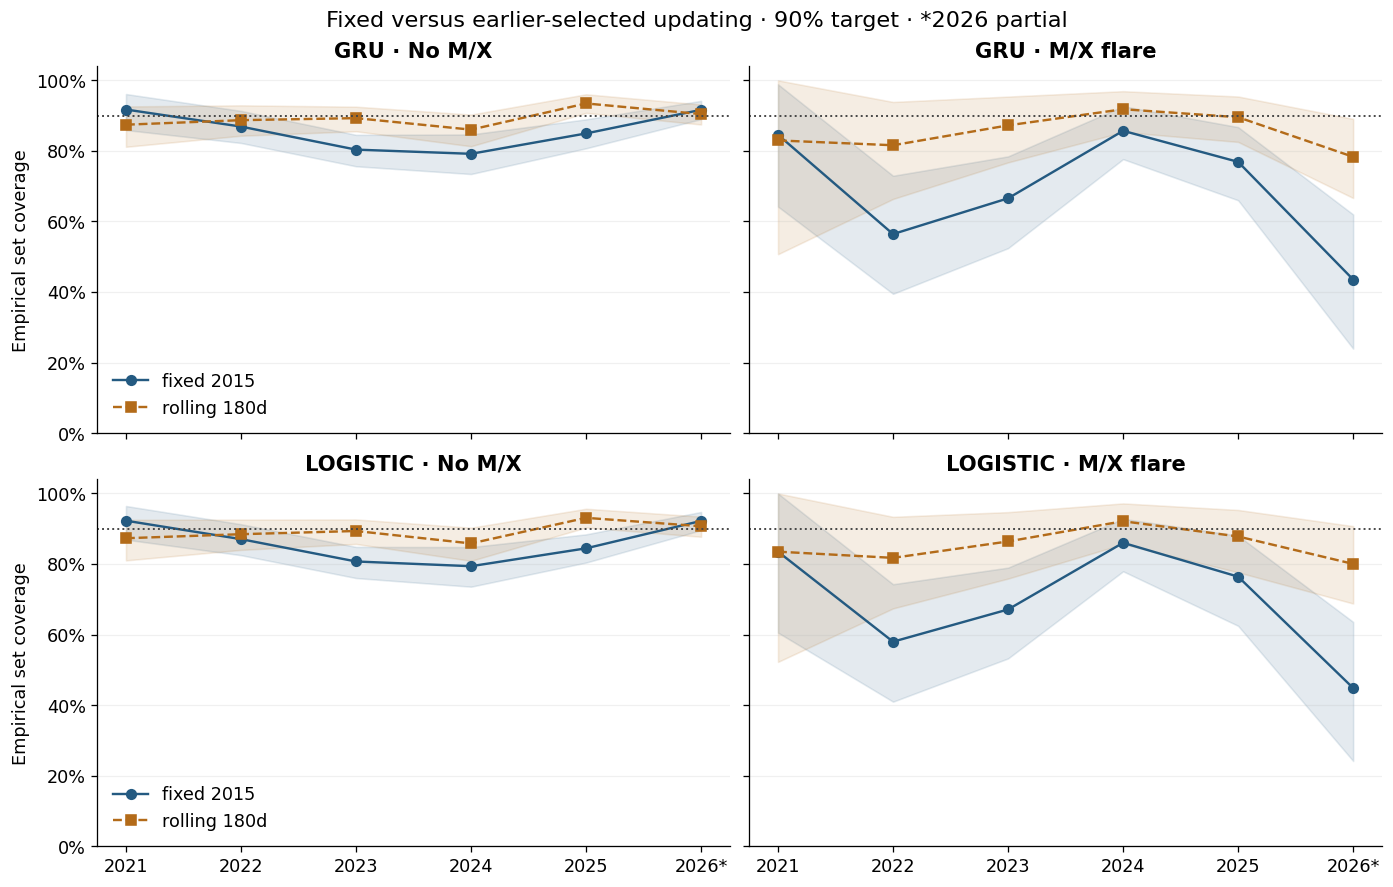

In [10]:
fig,axes=plt.subplots(2,2,figsize=(12,7.6),sharex=True,sharey=True,layout='constrained')
for row,model in enumerate(CONFIG['models']):
    chosen=selection['selected_methods'][model]
    methods=list(dict.fromkeys(['fixed_2015',chosen]))
    for col,population_name in enumerate(['nonflare','flare']):
        ax=axes[row,col]
        for method in methods:
            data=intervals[intervals.model.eq(model)&intervals.method.eq(method)&intervals.alpha.eq(.1)&intervals.population.eq(population_name)&intervals.year.ne('all')&intervals.grouping.eq('region_component')].copy()
            data['year']=data.year.astype(int);data=data.sort_values('year')
            fixed=method=='fixed_2015';color=COLORS['fixed_2015' if fixed else 'selected']
            ax.plot(data.year,data.coverage,marker='o' if fixed else 's',ls='-' if fixed else '--',color=color,label=method.replace('_',' '))
            ax.fill_between(data.year,data.low,data.high,color=color,alpha=.12)
        ax.axhline(.9,color='#444444',ls=':',lw=1.2)
        ax.set(title=f'{model.upper()} · {"No M/X" if population_name=="nonflare" else "M/X flare"}',ylim=(0,1.04),xticks=range(2021,2027),xticklabels=['2021','2022','2023','2024','2025','2026*'])
        ax.yaxis.set_major_formatter(PercentFormatter(1));ax.grid(axis='y',alpha=.18)
        if col==0:ax.set_ylabel('Empirical set coverage');ax.legend(loc='lower left',frameon=False)
fig.suptitle('Fixed versus earlier-selected updating · 90% target · *2026 partial',fontsize=14)
fig.savefig(OUTPUT_DIR/'annual_coverage.png',bbox_inches='tight');plt.show()

### 10. The cost in ambiguous forecasts
Bars contain only known-outcome evaluation windows. Missing inputs are not counted as empty sets. Colors and patterns distinguish the four possible set types.

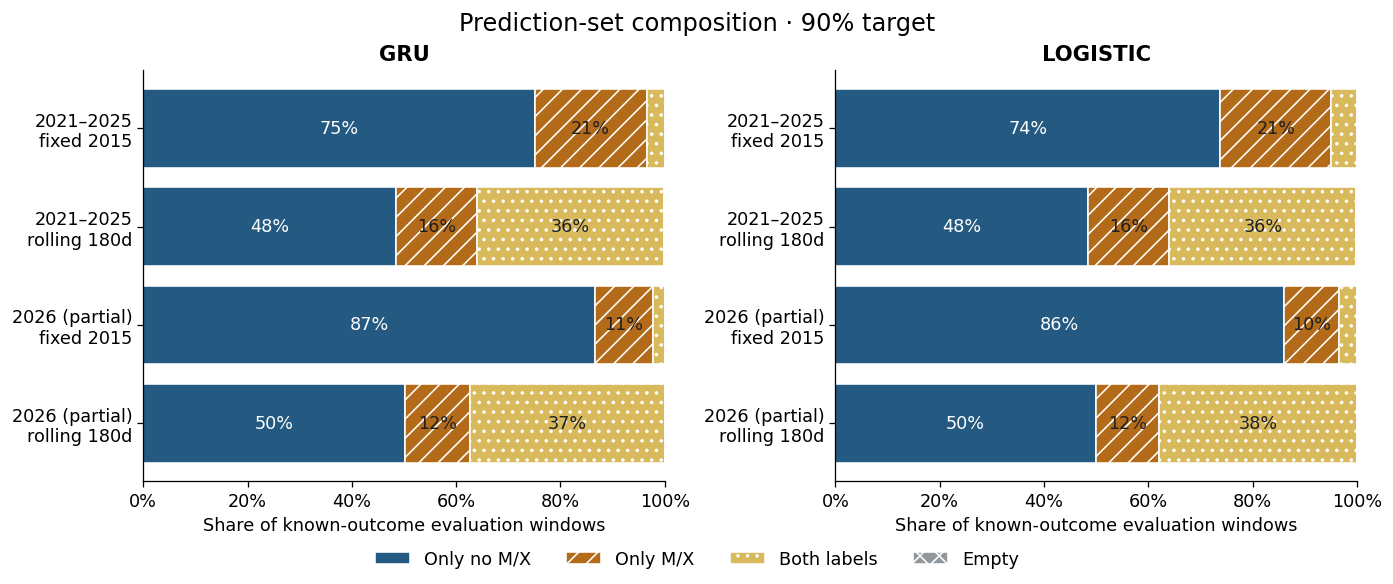

In [11]:
fig,axes=plt.subplots(1,2,figsize=(12,5),sharex=True,layout='constrained')
styles=[('nonflare_only','Only no M/X','#245A81',''),('flare_only','Only M/X','#B36B19','//'),('both','Both labels','#D8B95B','..'),('empty','Empty','#92979C','xx')]
for ax,model in zip(axes,CONFIG['models']):
    chosen=selection['selected_methods'][model]
    table=metrics[metrics.model.eq(model)&metrics.alpha.eq(.1)&(metrics.method.eq('fixed_2015')|metrics.method.eq(chosen))].copy()
    table['order']=table.role.map({'retrospective_cycle25':0,'supplementary_2026':2})+table.method.ne('fixed_2015').astype(int)
    table=table.sort_values('order');left=np.zeros(len(table))
    for state,label,color,hatch in styles:
        values=table[state+'_fraction'].to_numpy()
        ax.barh(range(len(table)),values,left=left,color=color,hatch=hatch,edgecolor='white',label=label)
        for i,width in enumerate(values):
            if width>=.07:ax.text(left[i]+width/2,i,f'{width:.0%}',ha='center',va='center',color='white' if state=='nonflare_only' else '#202020')
        left+=values
    ax.set(yticks=range(len(table)),yticklabels=[f'{PERIOD_NAMES[r.role]}\n{r.method.replace("_"," ")}' for r in table.itertuples()],xlim=(0,1),title=model.upper(),xlabel='Share of known-outcome evaluation windows')
    ax.invert_yaxis();ax.xaxis.set_major_formatter(PercentFormatter(1))
fig.legend(*axes[0].get_legend_handles_labels(),loc='outside lower center',ncol=4,frameon=False)
fig.suptitle('Prediction-set composition · 90% target',fontsize=15)
fig.savefig(OUTPUT_DIR/'set_composition.png',bbox_inches='tight');plt.show()

### 11. Low-support guards and ambiguity over time
Monthly fractions use known-outcome windows. A support guard automatically includes one or both classes; it is not a validated operational fallback. This chart helps identify coverage obtained during periods with insufficient recent calibration support.

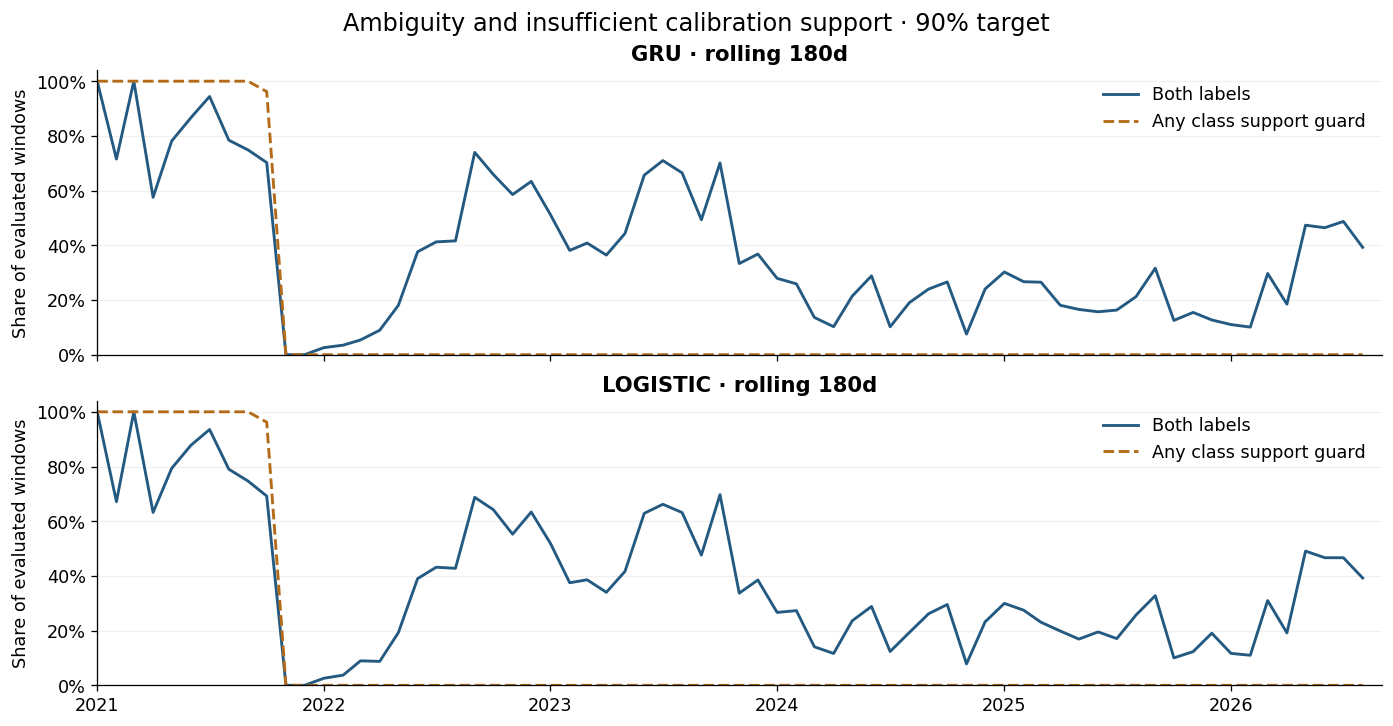

In [12]:
fig,axes=plt.subplots(2,1,figsize=(12,6.2),sharex=True,sharey=True,layout='constrained')
for ax,model in zip(axes,CONFIG['models']):
    chosen=selection['selected_methods'][model]
    data=monthly[monthly.model.eq(model)&monthly.method.eq(chosen)&monthly.alpha.eq(.1)].sort_values('month')
    dates=pd.to_datetime(data.month+'-01')
    ax.plot(dates,data.both_fraction,color='#245A81',label='Both labels',lw=1.8)
    ax.plot(dates,data.support_guard_fraction,color='#B36B19',ls='--',label='Any class support guard',lw=1.8)
    ax.set(title=f'{model.upper()} · {chosen.replace("_"," ")}',ylim=(0,1.04),ylabel='Share of evaluated windows')
    ax.yaxis.set_major_formatter(PercentFormatter(1));ax.grid(axis='y',alpha=.18)
    ax.legend(loc='upper right',frameon=False)
axes[-1].xaxis.set_major_locator(mdates.YearLocator());axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].set_xlim(pd.Timestamp('2021-01-01'),pd.Timestamp('2026-09-01'))
fig.suptitle('Ambiguity and insufficient calibration support · 90% target',fontsize=15)
fig.savefig(OUTPUT_DIR/'support_and_ambiguity.png',bbox_inches='tight');plt.show()

### 12. Paired differences and complete population
Intervals below compare the earlier-selected method with the fixed method on identical windows. They are conditional resampling sensitivities, not evidence of independent events or unconditional guarantees for the adaptive procedure.

In [13]:
if len(paired):
    display(paired[paired.alpha.eq(.1)&paired.grouping.eq('region_component')][['role','model','method','metric','difference','low','high']].round(4))
availability=pd.read_csv(OUTPUT_DIR/'availability.csv')
display(availability[availability.year.ge(2021)].reset_index(drop=True))
support=pd.read_csv(OUTPUT_DIR/'support_summary.csv')
display(support[support.model.eq('gru')&support.alpha.eq(.1)][['lookback_days','label','updates','guarded_updates','minimum_windows','median_windows','minimum_components']])
for name,expected in summary['output_sha256'].items():assert sha256(OUTPUT_DIR/name)==expected,name
for directory in [PARENT_DIR,FIXED_DIR]:
    parent=json.loads((directory/'summary.json').read_text())
    for name,expected in parent['output_sha256'].items():assert sha256(directory/name)==expected,name
print('All saved artifacts and frozen parents verified.')
print('Candidate population:',summary['population_rows'],'| Missing inputs:',summary['missing_input_rows'])

,role,model,method,metric,difference,low,high
0,retrospective_cycle25,gru,rolling_180d,coverage,0.0618,0.0504,0.0731
1,retrospective_cycle25,gru,rolling_180d,nonflare_coverage,0.0519,0.0410,0.0632
2,retrospective_cycle25,gru,rolling_180d,flare_coverage,0.1435,0.1017,0.1856
3,retrospective_cycle25,gru,rolling_180d,mean_set_size,0.3242,0.2999,0.3510
4,retrospective_cycle25,gru,rolling_180d,both_fraction,0.3251,0.3005,0.3517
20,retrospective_cycle25,logistic,rolling_180d,coverage,0.0584,0.0470,0.0687
21,retrospective_cycle25,logistic,rolling_180d,nonflare_coverage,0.0490,0.0383,0.0598
22,retrospective_cycle25,logistic,rolling_180d,flare_coverage,0.1358,0.0956,0.1758
23,retrospective_cycle25,logistic,rolling_180d,mean_set_size,0.3098,0.2862,0.3355
24,retrospective_cycle25,logistic,rolling_180d,both_fraction,0.3106,0.2869,0.3361


,year,candidate_cases,missing_inputs,sets_issued,issued_unknown_outcome
0,2021,5828,1253,4575,224
1,2022,11535,2525,9010,1371
2,2023,14676,3489,11187,1976
3,2024,14732,3359,11373,4301
4,2025,14774,5516,9258,1660
5,2026,14923,2764,12159,1041


,lookback_days,label,updates,guarded_updates,minimum_windows,median_windows,minimum_components
2,90,0,2975,203,0,1459.0,0
3,90,1,2975,1435,0,129.0,0
6,180,0,2975,137,0,3058.0,0
7,180,1,2975,943,0,277.0,0
10,365,0,2975,86,0,6175.0,0
11,365,1,2975,705,0,559.0,0


All saved artifacts and frozen parents verified.
Candidate population: 153366 | Missing inputs: 39933


## Takeaways

In [14]:
messages=[]
for model in CONFIG['models']:
    chosen=selection['selected_methods'][model]
    messages.append(f'**{model.upper()}:** earlier development selected **{chosen.replace("_"," ")}**.')
    for role in CONFIG['evaluation_roles']:
        rows=metrics[metrics.model.eq(model)&metrics.role.eq(role)&metrics.alpha.eq(.1)].set_index('method')
        fixed,selected=rows.loc['fixed_2015'],rows.loc[chosen]
        messages.append(f'{PERIOD_NAMES[role]}: flare coverage {fixed.flare_coverage:.1%} fixed → {selected.flare_coverage:.1%} selected; '
                        f'both-label sets {fixed.both_fraction:.1%} → {selected.both_fraction:.1%}; support guard on {selected.support_guard_fraction:.1%} of evaluated cases.')
display(Markdown('\n\n'.join(messages)))
display(Markdown('### Interpretation limits\n'+'\n'.join('- '+s for s in summary['limitations'])))

**GRU:** earlier development selected **rolling 180d**.

2021–2025: flare coverage 73.5% fixed → 87.9% selected; both-label sets 3.5% → 36.0%; support guard on 8.7% of evaluated cases.

2026 (partial): flare coverage 43.5% fixed → 78.3% selected; both-label sets 2.3% → 37.4%; support guard on 0.0% of evaluated cases.

**LOGISTIC:** earlier development selected **rolling 180d**.

2021–2025: flare coverage 73.9% fixed → 87.5% selected; both-label sets 4.9% → 35.9%; support guard on 8.7% of evaluated cases.

2026 (partial): flare coverage 44.9% fixed → 80.0% selected; both-label sets 3.5% → 37.9%; support guard on 0.0% of evaluated cases.

### Interpretation limits
- Candidate labels and outcome-coverage/availability limitations remain provisional; 24-hour reporting latency is assumed, not reconstructed.
- The method was designed after viewing earlier retrospective results. This is an exploratory extension, not untouched confirmatory validation.
- The predictor and probability mapping stay frozen, but rolling calibration uses matured earlier Cycle-25/2026 labels. It is not label-free cross-cycle transfer.
- Rolling quantiles with fixed alpha are not adaptive conformal inference with an error-feedback controller, and no distribution-free coverage guarantee is claimed under drift/dependence.
- Daily updates use the available native issue-time cohort, not a complete operational forecast schedule. No 2020 scored cases are available in this snapshot.
- Low-support guards deliberately include unsupported classes, potentially yielding both labels. This can improve coverage by sacrificing useful specificity.
- Selection minimizes point-estimate class coverage deficit then mean set size on one earlier policy block; this does not certify class coverage or safety.
- Forecast windows overlap. Bootstrap intervals condition on the realized sequential forecasts and do not rerun adaptation or include calibration/model/label uncertainty.
- No operational decision-state policy, prospective deployment, AIA fusion or continuous-target quantile regression is validated here.

The next policy experiment must balance class coverage, incorrect decisive forecasts and forecast availability, including missing inputs and low-support periods. A singleton alone does not establish a trustworthy forecast. The earlier development block has now informed rolling-method selection; further tuning and validation must report that reuse transparently. AIA fusion and genuinely prospective logged forecasts remain later work.

**Reusable artifacts:** daily threshold journal with support and availability checks, full-population set codes, frozen earlier selection, all candidate metrics, monthly/yearly results, paired intervals and a source/runtime/hash contract. Per-case outputs remain local; compact receipts and the executed notebook are versioned.